## Genetic Algorithm Feature Selection

### Load and Preprocess Data

In [14]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import random
import joblib

from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder

np.random.seed(42)
random.seed(42)

In [16]:
# Load data in dataframe
train_student_data = pd.read_csv("../data/train.csv")
test_student_data = pd.read_csv("../data/test.csv")

# Drop ID column (redundant)
id_data = test_student_data["id"] # Save ID for submission
train_student_data = train_student_data.drop(columns=["id"])
test_student_data = test_student_data.drop(columns=["id"])

# Make Internet Access Binary (Yes = 1, No =0)
train_student_data["internet_access"] = train_student_data["internet_access"].map({"yes": 1, "no": 0})
test_student_data["internet_access"] = test_student_data["internet_access"].map({"yes": 1, "no": 0})    

# One Hot Encode remaining categorical features
categorical_features = ["gender","course","sleep_quality","study_method","facility_rating","exam_difficulty"]
one_hot_data = train_student_data[categorical_features]

encoder = OneHotEncoder(drop="first", sparse_output=False) # Avoid multicollinearity

one_hot_encoded = encoder.fit_transform(one_hot_data)
one_hot_names = encoder.get_feature_names_out(categorical_features)

# Replace existing categorical rows
train_student_data = pd.concat(
    [train_student_data.drop(columns=categorical_features), pd.DataFrame(one_hot_encoded, columns=one_hot_names)],
    axis=1
)

test_student_data = pd.concat(
    [test_student_data.drop(columns=categorical_features), pd.DataFrame(encoder.transform(test_student_data[categorical_features]), columns=one_hot_names)],
    axis=1
)

# Split features and target
target = "exam_score"
features = list(train_student_data.columns)
features.remove(target)

X = train_student_data[features]
y = train_student_data[target]
X_submission = test_student_data[features]

# Split training data into train/validation (80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

### Build Initial Population

In [ ]:
# Building a population of original linear regression solutions (50 total)

# All Features (Baseline) - All 1s
feature_count = len(features)
baseline = [1] * feature_count

# Build population of similar solutions (Exploitation)
pop = []
pop.append(baseline.copy())

for i in range(10): # Population size of 10
    ind = baseline.copy()

    # Randomly Exclude 10% of features
    for j in range(feature_count):
        if np.random.rand() < 0.1:
            ind[j] = 0 # Feature excluded
    pop.append(ind)


# Build population of random solutions (Exploration)
for i in range(50): # Population size of 50
    ind = []
    for j in range(feature_count):
        ind.append(1 if np.random.rand() > 0.5 else 0) # Randomly include/exclude features with 50% chance
    pop.append(ind)

# print (pop)

### GA Operators

In [18]:
# Utility: get selected feature indices from binary chromosome
def selected_cols(individual):
    cols = [i for i, bit in enumerate(individual) if bit == 1]
    if len(cols) == 0:
        cols = [np.random.randint(0, len(individual))]  # ensure at least one feature
    return cols

# Fitness = CV RMSE + sparsity penalty (lower is better)
def calculate_fitness(individual, alpha=0.01):
    cols = selected_cols(individual)
    X_sel = X_train.iloc[:, cols]

    model = LinearRegression()
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    rmse = -cross_val_score(
        model,
        X_sel,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=cv,
    ).mean()

    penalty = alpha * (len(cols) / len(individual))
    return rmse + penalty

In [19]:
# Tournament selection (lower fitness is better)
def tournament_select(population, fitnesses, selected_count, tournament_size=3):
    selected = []
    pop_idx = list(range(len(population)))

    for _ in range(selected_count):
        contestants = random.sample(pop_idx, k=tournament_size)
        winner = min(contestants, key=lambda i: fitnesses[i])
        selected.append(population[winner])

    return selected

In [20]:
# Uniform Crossover (Equal chance to inherit from either parent)
def crossover (p1, p2):
    child = []

    # Child inherits has 50% chance to inherit each feature from either parent
    for i in range(len(p1)):
        child.append(p1[i] if np.random.rand() > 0.5 else p2[i])
    return child

In [21]:
# Mutation encourages exploration
def mutate(individual, mutation_rate=0.03):
    child = individual.copy()

    # Each feature has a small chance to flip
    for i in range(len(child)):
        if np.random.rand() < mutation_rate:
            child[i] = 1 - child[i]

    # Ensure at least one selected feature
    if sum(child) == 0:
        child[np.random.randint(0, len(child))] = 1

    return child

### Run Genetic Algorithm

In [22]:
# GA hyperparameters
n_generations = 50
elite_count = 4
parent_count = max(12, int(len(pop) * 0.3))
mutation_rate = 0.05

best_history = []

for gen in range(n_generations):
    # Evaluate population
    fitnesses = [calculate_fitness(ind) for ind in pop]
    ranked_idx = np.argsort(fitnesses)

    # Elitism: keep top individuals
    elites = [pop[i][:] for i in ranked_idx[:elite_count]]

    # Select parents with tournament selection
    parents = tournament_select(pop, fitnesses, selected_count=parent_count, tournament_size=3)

    # Rebuild next generation
    new_pop = elites.copy()
    while len(new_pop) < len(pop):
        p1, p2 = random.sample(parents, 2)
        child = crossover(p1, p2)
        child = mutate(child, mutation_rate=mutation_rate)
        new_pop.append(child)

    pop = new_pop

    best_fit = min(fitnesses)
    best_history.append(best_fit)
    print(f"gen {gen + 1}/{n_generations} | best fitness: {best_fit:.4f}")

gen 1/50 | best fitness: 8.9058
gen 2/50 | best fitness: 8.9054
gen 3/50 | best fitness: 8.9053
gen 4/50 | best fitness: 8.9049
gen 5/50 | best fitness: 8.9049
gen 6/50 | best fitness: 8.9049
gen 7/50 | best fitness: 8.9046
gen 8/50 | best fitness: 8.9045
gen 9/50 | best fitness: 8.9043
gen 10/50 | best fitness: 8.9038
gen 11/50 | best fitness: 8.9038
gen 12/50 | best fitness: 8.9038
gen 13/50 | best fitness: 8.9038
gen 14/50 | best fitness: 8.9037
gen 15/50 | best fitness: 8.9037
gen 16/50 | best fitness: 8.9034
gen 17/50 | best fitness: 8.9032
gen 18/50 | best fitness: 8.9032
gen 19/50 | best fitness: 8.9032
gen 20/50 | best fitness: 8.9032
gen 21/50 | best fitness: 8.9032
gen 22/50 | best fitness: 8.9031
gen 23/50 | best fitness: 8.9031
gen 24/50 | best fitness: 8.9031
gen 25/50 | best fitness: 8.9031
gen 26/50 | best fitness: 8.9031
gen 27/50 | best fitness: 8.9031
gen 28/50 | best fitness: 8.9031
gen 29/50 | best fitness: 8.9031
gen 30/50 | best fitness: 8.9031
gen 31/50 | best fi

Selected features: 13 of 23
Best fitness (CV RMSE + penalty): 8.9031
First selected feature names: ['study_hours', 'class_attendance', 'sleep_hours', 'gender_other', 'course_b.sc', 'sleep_quality_good', 'sleep_quality_poor', 'study_method_group study', 'study_method_mixed', 'study_method_online videos', 'study_method_self-study', 'facility_rating_low', 'facility_rating_medium']


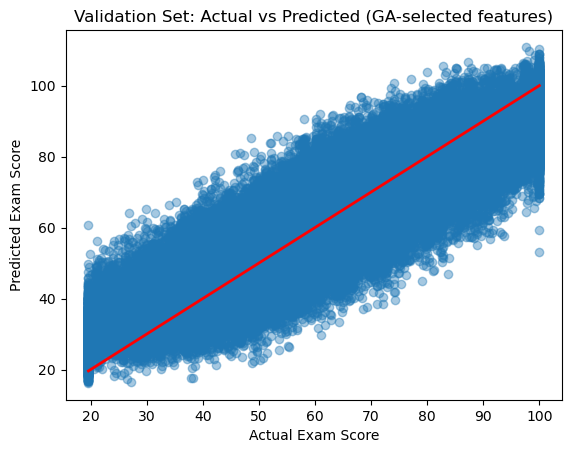

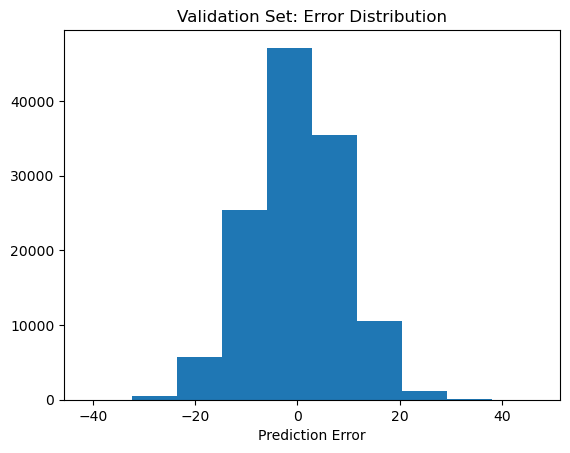

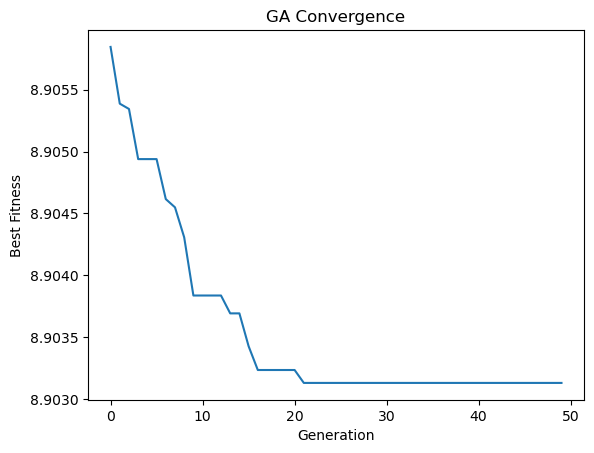

Metrics saved to ../metrics/genetic_algorithm_metrics.csv


,MAE,MSE,RMSE,R2
0,7.093398,78.970289,8.886523,0.777953


In [ ]:
# Output GA results
fitnesses = [calculate_fitness(ind) for ind in pop]
best_idx = int(np.argmin(fitnesses))
best_individual = pop[best_idx]
best_fitness = fitnesses[best_idx]
best_cols = selected_cols(best_individual)
selected_feature_names = [features[i] for i in best_cols]

# Train model using selected features only
ga_model = LinearRegression()
ga_model.fit(X_train.iloc[:, best_cols], y_train)

print("Selected features:", len(best_cols), "of", len(features))
print("Best fitness (CV RMSE + penalty):", round(best_fitness, 4))
print("First selected feature names:", selected_feature_names[:15])

# Evaluate on validation data
y_val_pred = ga_model.predict(X_val.iloc[:, best_cols])

# Actual vs Predicted
plt.scatter(y_val, y_val_pred, alpha=0.4)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r", lw=2)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Validation Set: Actual vs Predicted (GA-selected features)")
plt.show()

# Error distribution
plt.hist(y_val - y_val_pred)
plt.xlabel("Prediction Error")
plt.title("Validation Set: Error Distribution")
plt.show()

# Best-fitness trend
plt.plot(best_history)
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("GA Convergence")
plt.show()

# Metrics
pd.set_option("float_format", "{:f}".format)
res_metrics = pd.DataFrame({
    "MAE": [metrics.mean_absolute_error(y_val, y_val_pred)],
    "MSE": [metrics.mean_squared_error(y_val, y_val_pred)],
    "RMSE": [np.sqrt(metrics.mean_squared_error(y_val, y_val_pred))],
    "R2": [metrics.r2_score(y_val, y_val_pred)],
})
res_metrics.to_csv("../metrics/genetic_algorithm_metrics.csv", index=False)
print("Metrics saved to ../metrics/genetic_algorithm_metrics.csv")
res_metrics

### Generate Submission

In [25]:
# Generate submission predictions using contest test set
exam_score = ga_model.predict(X_submission.iloc[:, best_cols])

df_ga = pd.DataFrame({
    "id": id_data,
    "exam_score": exam_score
})
df_ga.to_csv("../output csv/genetic_algorithm_submission.csv", index=False)
print("Submission saved to ../output csv/genetic_algorithm_submission.csv")
df_ga

Submission saved to ../output csv/genetic_algorithm_submission.csv


,id,exam_score
0,630000,71.958808
1,630001,69.411324
2,630002,87.353957
3,630003,54.929960
4,630004,47.131568
...,...,...
269995,899995,61.044249
269996,899996,38.913720
269997,899997,89.906654
269998,899998,55.630672


In [ ]:
# Save model
joblib.dump(ga_model, "../models/genetic_algorithm.pkl")
print("Model saved to ../models/genetic_algorithm.pkl")

Model saved to ../models/genetic_algorithm.pkl
